Use Models From previous solutions notebooks

Now import dataset and run models on Black Scholes

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import statsmodels.api as sm
from black_scholes import BlackScholesSimulator


# create the Black-Scholes dataset
simulator = BlackScholesSimulator()

# generate the dataset inside a df
train_df, test_df = simulator.generate_option_dataset()

# Define features and target
X_train = train_df[["Stock Price", "Strike Price", "Time to Expiration", "Risk-Free Rate", "Volatility"]]
y_train = train_df["Option Price"]
X_test = test_df[["Stock Price", "Strike Price", "Time to Expiration", "Risk-Free Rate", "Volatility"]]
y_test = test_df["Option Price"]

# No rescale as we already do it inside BlackScholesSimulator

# generate a noisier dataset
noisy_train_df, noisy_test_df = simulator.generate_option_dataset(noise_var=5)
X_noisy_test = noisy_test_df[["Stock Price", "Strike Price", "Time to Expiration", "Risk-Free Rate", "Volatility"]]
y_noisy_test = noisy_test_df["Option Price"]
X_noisy_train = noisy_train_df[["Stock Price", "Strike Price", "Time to Expiration", "Risk-Free Rate", "Volatility"]]
y_noisy_train = noisy_train_df["Option Price"]


Now run the models on new dataset

1 - Linear Regression

Training set: 1083456 samples
Testing set: 270864 samples

Linear Regression Results:
Coefficients: [ 4.94709697 -7.52583367  2.31919604  0.35806787  2.63310786]
Intercept: 13.069378
Training R-squared: 0.848413
Testing R-squared: 0.848616
Training MSE: 16.712884
Testing MSE: 16.691329
Training MAE: 3.237389
Testing MAE: 3.234924

Performance on Noisier Data:
MSE: 34.566247
R-squared: 0.715150

Detailed Regression Results (statsmodels):
                            OLS Regression Results                            
Dep. Variable:           Option Price   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                 1.213e+06
Date:                Sat, 05 Apr 2025   Prob (F-statistic):               0.00
Time:                        21:37:11   Log-Likelihood:            -3.0630e+06
No. Observations:             1083456   AIC:                         6.126e+06
Df Res

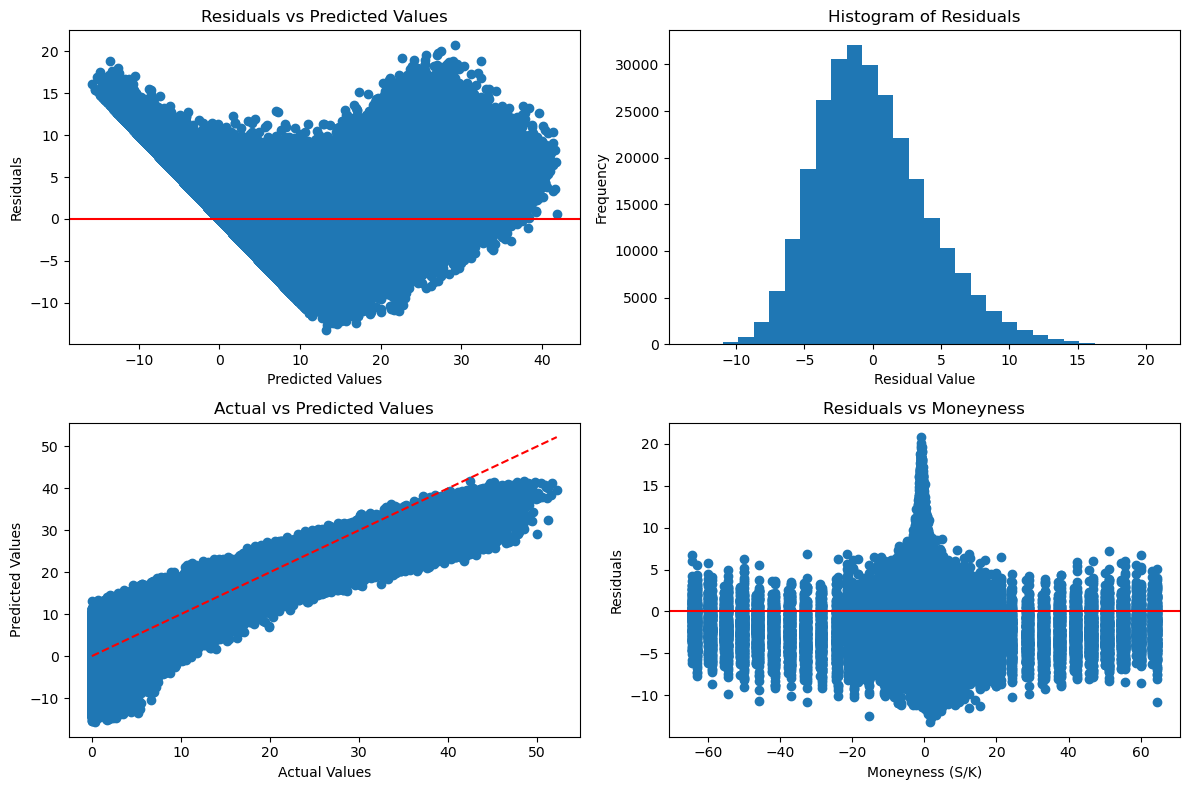


Performance by Moneyness Category for Linear:
Deep OTM Options - Count: 54501, MSE: 10.044769, R²: 0.859749
OTM Options - Count: 10418, MSE: 11.128603, R²: 0.709322
ATM Options - Count: 6484, MSE: 11.831400, R²: 0.649157
ITM Options - Count: 7684, MSE: 13.896705, R²: 0.537523
Deep ITM Options - Count: 56439, MSE: 16.222311, R²: 0.562163


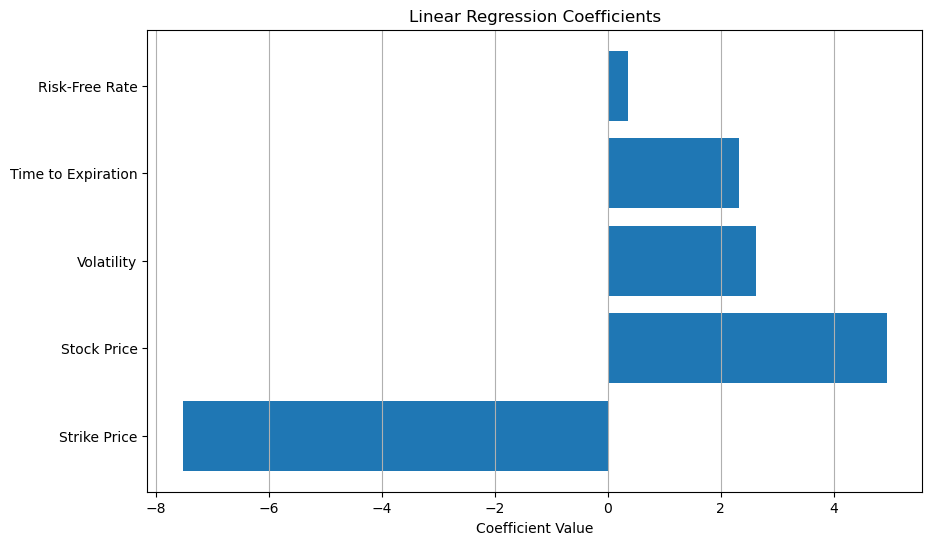

In [21]:
# 6. Make predictions with each model

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# 4. Linear Regression with sklearn
linear = LinearRegression()
linear.fit(X_train, y_train)

# Get predictions on both training and testing data
y_train_pred = linear.predict(X_train)
y_test_pred = linear.predict(X_test)

# Print results
print("\nLinear Regression Results:")
print(f"Coefficients: {linear.coef_}")
print(f"Intercept: {linear.intercept_:.6f}")
print(f"Training R-squared: {r2_score(y_train, y_train_pred):.6f}")
print(f"Testing R-squared: {r2_score(y_test, y_test_pred):.6f}")
print(f"Training MSE: {mean_squared_error(y_train, y_train_pred):.6f}")
print(f"Testing MSE: {mean_squared_error(y_test, y_test_pred):.6f}")
print(f"Training MAE: {mean_absolute_error(y_train, y_train_pred):.6f}")
print(f"Testing MAE: {mean_absolute_error(y_test, y_test_pred):.6f}")

# Generate higher noise test set to check generalization
y_noisy_test_pred = linear.predict(X_noisy_test)

print("\nPerformance on Noisier Data:")
print(f"MSE: {mean_squared_error(y_noisy_test, y_noisy_test_pred):.6f}")
print(f"R-squared: {r2_score(y_noisy_test, y_noisy_test_pred):.6f}")

# Use statsmodels for detailed regression statistics
X_sm = sm.add_constant(X_train)  # Add a constant for the intercept
model_sm = sm.OLS(y_train, X_sm).fit()

# Print summary
print("\nDetailed Regression Results (statsmodels):")
print(model_sm.summary())

# Analyze residuals
residuals = y_test - y_test_pred

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

plt.subplot(2, 2, 2)
plt.hist(residuals, bins=30)
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')

plt.subplot(2, 2, 3)
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

# Calculate moneyness for analysis
test_df['Moneyness'] = test_df['Stock Price'] / test_df['Strike Price']
test_df['Predicted'] = y_test_pred
test_df['Residuals'] = residuals

plt.subplot(2, 2, 4)
plt.scatter(test_df['Moneyness'], test_df['Residuals'])
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Moneyness (S/K)')
plt.ylabel('Residuals')
plt.title('Residuals vs Moneyness')

plt.tight_layout()
plt.show()

# Analyze performance by moneyness
test_df['Moneyness_Category'] = pd.cut(
    test_df['Moneyness'], 
    bins=[0, 0.8, 0.95, 1.05, 1.2, float('inf')],
    labels=['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']
)

print("\nPerformance by Moneyness Category for Linear:")
for category in ['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']:
    category_df = test_df[test_df['Moneyness_Category'] == category]
    if len(category_df) > 0:
        category_mse = mean_squared_error(category_df['Option Price'], category_df['Predicted'])
        category_r2 = r2_score(category_df['Option Price'], category_df['Predicted'])
        print(f"{category} Options - Count: {len(category_df)}, MSE: {category_mse:.6f}, R²: {category_r2:.6f}")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linear.coef_,
    'Abs_Coefficient': np.abs(linear.coef_)
})
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients')
plt.grid(axis='x')
plt.show()

2 - Lasso

Best alpha: 0.0001

Lasso Regression Results:
Coefficients: [ 4.94699687 -7.52573369  2.31909609  0.35796795  2.63300796]
Intercept: 13.069378

Training Metrics:
R-squared: 0.848413
MSE: 16.712884
MAE: 3.237397

Testing Metrics:
R-squared: 0.848616
MSE: 16.691330
MAE: 3.234931

Feature Importance:
              Feature  Coefficient  Abs_Coefficient
1        Strike Price    -7.525734         7.525734
0         Stock Price     4.946997         4.946997
4          Volatility     2.633008         2.633008
2  Time to Expiration     2.319096         2.319096
3      Risk-Free Rate     0.357968         0.357968

Number of features used (non-zero coefficients): 5

Performance on Noisier Data:
MSE: 34.566110
R-squared: 0.715151


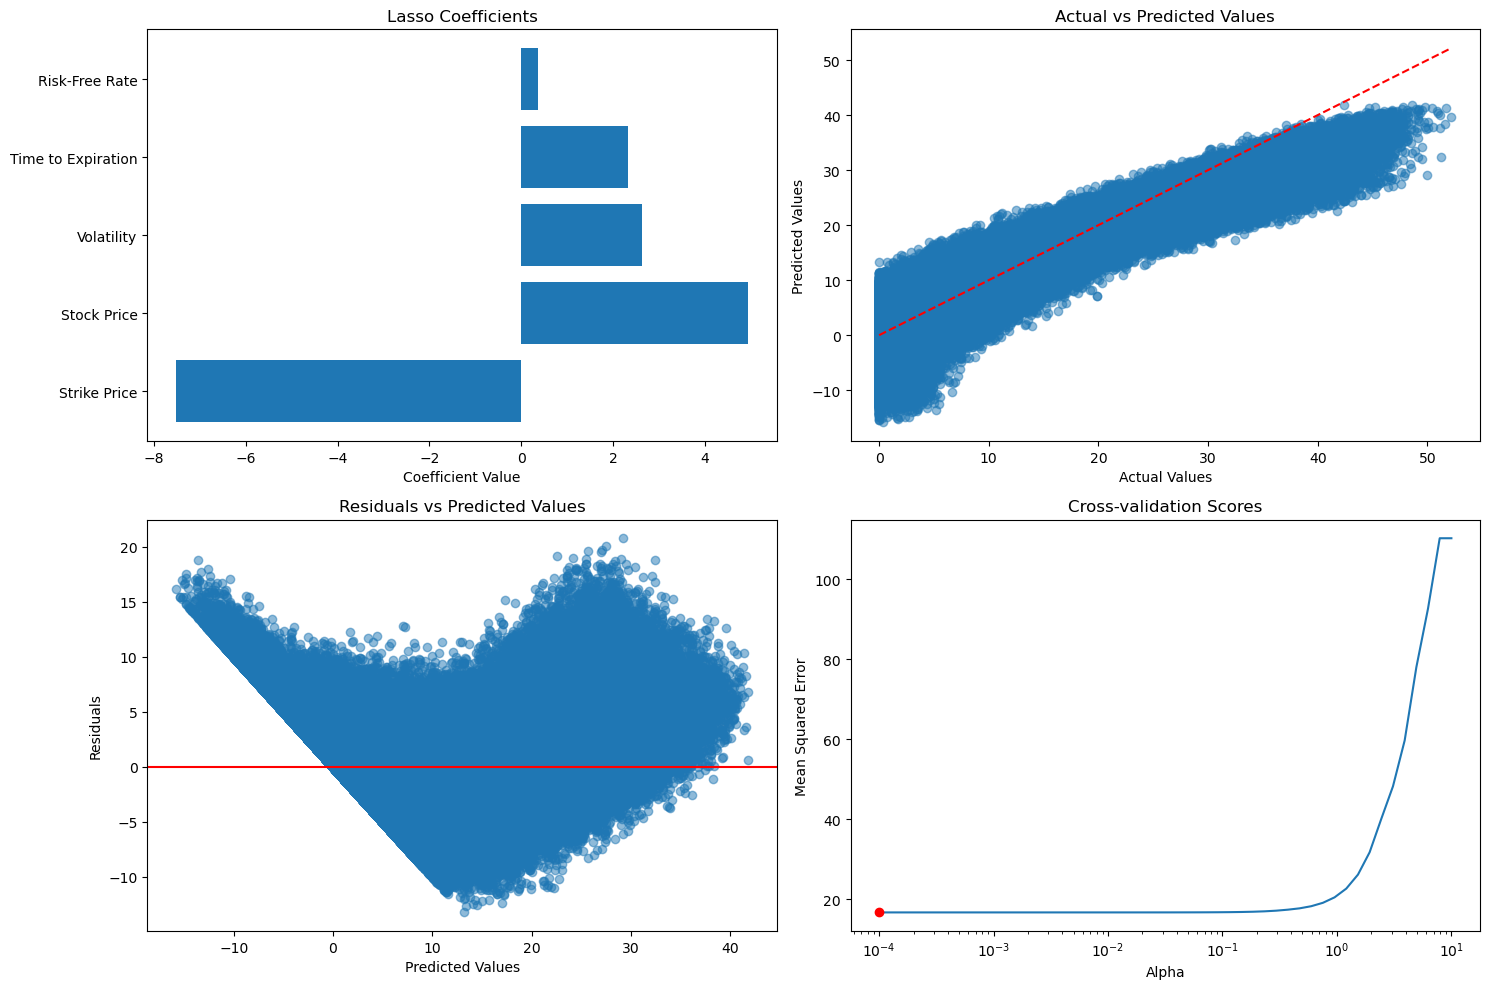


Performance by Moneyness Category (Lasso):
Deep OTM Options - Count: 54501, MSE: 10.044788, R²: 0.859748
OTM Options - Count: 10418, MSE: 11.128741, R²: 0.709319
ATM Options - Count: 6484, MSE: 11.831586, R²: 0.649151
ITM Options - Count: 7684, MSE: 13.896963, R²: 0.537514
Deep ITM Options - Count: 56439, MSE: 16.222628, R²: 0.562154


In [ ]:
# Perform Grid Search to find the best alpha
alphas = np.logspace(-4, 1, 50)
param_grid = {'alpha': alphas}
lasso_grid = GridSearchCV(
    Lasso(random_state=42, max_iter=10000),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
lasso_grid.fit(X_train, y_train)

# Get best alpha and train final model
best_alpha = lasso_grid.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

lasso = Lasso(alpha=best_alpha, random_state=42)
lasso.fit(X_train, y_train)

# Get predictions
y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

# Print performance metrics
print("\nLasso Regression Results:")
print(f"Coefficients: {lasso.coef_}")
print(f"Intercept: {lasso.intercept_:.6f}")
print("\nTraining Metrics:")
print(f"R-squared: {r2_score(y_train, y_train_pred):.6f}")
print(f"MSE: {mean_squared_error(y_train, y_train_pred):.6f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.6f}")
print("\nTesting Metrics:")
print(f"R-squared: {r2_score(y_test, y_test_pred):.6f}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred):.6f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.6f}")

# Analyze feature importance and sparsity
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso.coef_,
    'Abs_Coefficient': np.abs(lasso.coef_)
})
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("\nFeature Importance:")
print(feature_importance)
print(f"\nNumber of features used (non-zero coefficients): {np.sum(lasso.coef_ != 0)}")

# Generate higher noise test set to check generalization
y_noisy_test_pred = lasso.predict(X_noisy_test)

print("\nPerformance on Noisier Data:")
print(f"MSE: {mean_squared_error(y_noisy_test, y_noisy_test_pred):.6f}")
print(f"R-squared: {r2_score(y_noisy_test, y_noisy_test_pred):.6f}")

# Visualization
plt.figure(figsize=(15, 10))

# Plot 1: Feature Importance
plt.subplot(2, 2, 1)
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.title('Lasso Coefficients')
plt.xlabel('Coefficient Value')

# Plot 2: Actual vs Predicted
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

# Plot 3: Residuals
residuals = y_test - y_test_pred
plt.subplot(2, 2, 3)
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

# Plot 4: Cross-validation scores
plt.subplot(2, 2, 4)
cv_results = pd.DataFrame(lasso_grid.cv_results_)
plt.semilogx(alphas, -cv_results['mean_test_score'])
plt.plot(best_alpha, -cv_results['mean_test_score'][lasso_grid.best_index_], 'ro')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Cross-validation Scores')

plt.tight_layout()
plt.show()

# Analyze performance by moneyness
test_df['Moneyness'] = test_df['Stock Price'] / test_df['Strike Price']
test_df['Predicted'] = y_test_pred
test_df['Residuals'] = residuals

test_df['Moneyness_Category'] = pd.cut(
    test_df['Moneyness'], 
    bins=[0, 0.8, 0.95, 1.05, 1.2, float('inf')],
    labels=['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']
)

print("\nPerformance by Moneyness Category (Lasso):")
for category in ['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']:
    category_df = test_df[test_df['Moneyness_Category'] == category]
    if len(category_df) > 0:
        category_mse = mean_squared_error(category_df['Option Price'], category_df['Predicted'])
        category_r2 = r2_score(category_df['Option Price'], category_df['Predicted'])
        print(f"{category} Options - Count: {len(category_df)}, MSE: {category_mse:.6f}, R²: {category_r2:.6f}")

3 - Ridge

Best alpha: 0.0001

Ridge Regression Results:
Coefficients: [ 4.94709697 -7.52583367  2.31919604  0.35806787  2.63310786]
Intercept: 13.069378

Training Metrics:
R-squared: 0.848413
MSE: 16.712884
MAE: 3.237389

Testing Metrics:
R-squared: 0.848616
MSE: 16.691329
MAE: 3.234924

Feature Importance:
              Feature  Coefficient  Abs_Coefficient
1        Strike Price    -7.525834         7.525834
0         Stock Price     4.947097         4.947097
4          Volatility     2.633108         2.633108
2  Time to Expiration     2.319196         2.319196
3      Risk-Free Rate     0.358068         0.358068

Performance on Noisier Data:
MSE: 34.566247
R-squared: 0.715150


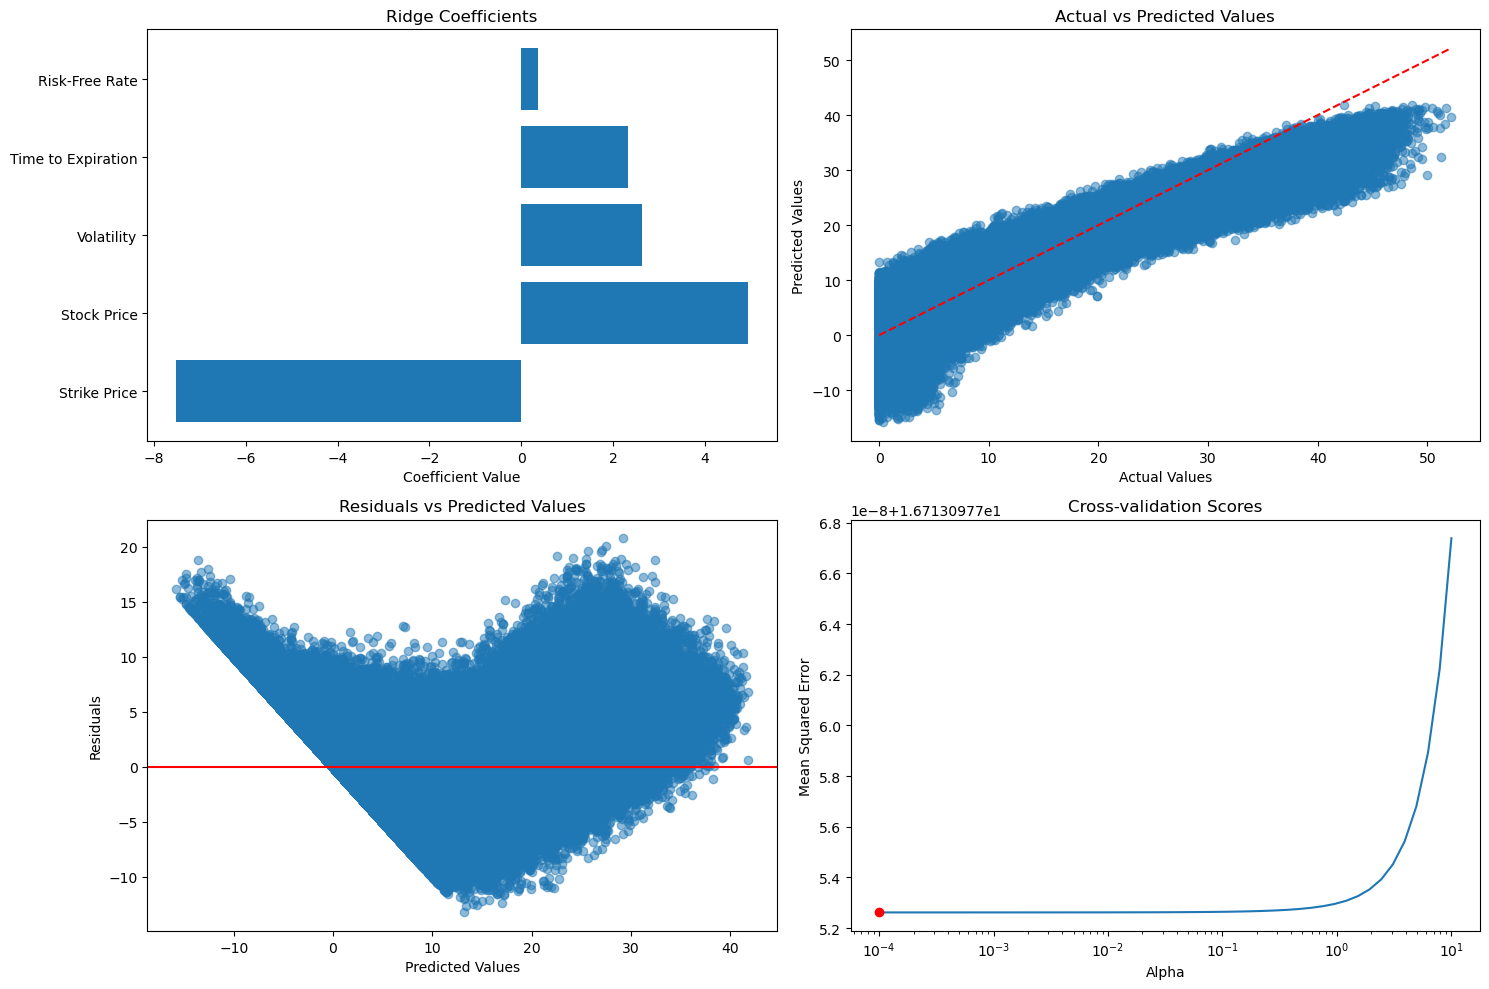


Performance by Moneyness Category (Ridge):
Deep OTM Options - Count: 54501, MSE: 10.044769, R²: 0.859749
OTM Options - Count: 10418, MSE: 11.128603, R²: 0.709322
ATM Options - Count: 6484, MSE: 11.831400, R²: 0.649157
ITM Options - Count: 7684, MSE: 13.896705, R²: 0.537523
Deep ITM Options - Count: 56439, MSE: 16.222311, R²: 0.562163


In [ ]:

# Perform Grid Search to find the best alpha
alphas = np.logspace(-4, 1, 50)
param_grid = {'alpha': alphas}
ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
ridge_grid.fit(X_train, y_train)

# Get best alpha and train final model
best_alpha = ridge_grid.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

ridge = Ridge(alpha=best_alpha, random_state=42)
ridge.fit(X_train, y_train)

# Get predictions
y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

# Print performance metrics
print("\nRidge Regression Results:")
print(f"Coefficients: {ridge.coef_}")
print(f"Intercept: {ridge.intercept_:.6f}")
print("\nTraining Metrics:")
print(f"R-squared: {r2_score(y_train, y_train_pred):.6f}")
print(f"MSE: {mean_squared_error(y_train, y_train_pred):.6f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.6f}")
print("\nTesting Metrics:")
print(f"R-squared: {r2_score(y_test, y_test_pred):.6f}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred):.6f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.6f}")

# Analyze feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': ridge.coef_,
    'Abs_Coefficient': np.abs(ridge.coef_)
})
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Evaluate on noisier data
y_noisy_test_pred = ridge.predict(X_noisy_test)

print("\nPerformance on Noisier Data:")
print(f"MSE: {mean_squared_error(y_noisy_test, y_noisy_test_pred):.6f}")
print(f"R-squared: {r2_score(y_noisy_test, y_noisy_test_pred):.6f}")

# Visualization
plt.figure(figsize=(15, 10))

# Plot 1: Feature Importance
plt.subplot(2, 2, 1)
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.title('Ridge Coefficients')
plt.xlabel('Coefficient Value')

# Plot 2: Actual vs Predicted
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

# Plot 3: Residuals
residuals = y_test - y_test_pred
plt.subplot(2, 2, 3)
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

# Plot 4: Cross-validation scores
plt.subplot(2, 2, 4)
cv_results = pd.DataFrame(ridge_grid.cv_results_)
plt.semilogx(alphas, -cv_results['mean_test_score'])
plt.plot(best_alpha, -cv_results['mean_test_score'][ridge_grid.best_index_], 'ro')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Cross-validation Scores')

plt.tight_layout()
plt.show()

# Analyze performance by moneyness
test_df['Moneyness'] = test_df['Stock Price'] / test_df['Strike Price']
test_df['Predicted'] = y_test_pred
test_df['Residuals'] = residuals

test_df['Moneyness_Category'] = pd.cut(
    test_df['Moneyness'], 
    bins=[0, 0.8, 0.95, 1.05, 1.2, float('inf')],
    labels=['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']
)

print("\nPerformance by Moneyness Category (Ridge):")
for category in ['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']:
    category_df = test_df[test_df['Moneyness_Category'] == category]
    if len(category_df) > 0:
        category_mse = mean_squared_error(category_df['Option Price'], category_df['Predicted'])
        category_r2 = r2_score(category_df['Option Price'], category_df['Predicted'])
        print(f"{category} Options - Count: {len(category_df)}, MSE: {category_mse:.6f}, R²: {category_r2:.6f}")


Non Linear Analysis

In [22]:

from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings

def add_nonlinear_features(X_df):
    """Add Black-Scholes inspired features with robust error handling"""
    X_new = X_df.copy()
    eps = 1e-10  # Small constant to avoid division by zero
    
    # Basic features with safety checks
    X_new['Moneyness'] = X_df['Stock Price'] / (X_df['Strike Price'] + eps)
    X_new['Time_Sqrt'] = np.sqrt(np.maximum(X_df['Time to Expiration'], eps))
    X_new['Discount'] = np.exp(-X_df['Risk-Free Rate'] * X_df['Time to Expiration'])
    
    # Volatility adjusted time
    X_new['Vol_Time'] = X_df['Volatility'] * X_new['Time_Sqrt']
    
    # Black-Scholes d1 and d2 components
    X_new['d1'] = (np.log(X_new['Moneyness']) + 
                   (X_df['Risk-Free Rate'] + 0.5 * X_df['Volatility']**2) * 
                   X_df['Time to Expiration']) / (X_new['Vol_Time'] + eps)
    X_new['d2'] = X_new['d1'] - X_new['Vol_Time']
    
    # Clip extreme values
    X_new['d1'] = np.clip(X_new['d1'], -5, 5)
    X_new['d2'] = np.clip(X_new['d2'], -5, 5)
    
    # Black-Scholes probability components
    X_new['N_d1'] = norm.cdf(X_new['d1'])
    X_new['N_d2'] = norm.cdf(X_new['d2'])
    
    # Option components
    X_new['S_N_d1'] = X_df['Stock Price'] * X_new['N_d1']
    X_new['K_Disc_N_d2'] = X_df['Strike Price'] * X_new['Discount'] * X_new['N_d2']
    
    # Intrinsic value
    X_new['Intrinsic'] = np.maximum(0, X_df['Stock Price'] - X_df['Strike Price'])
    
    # Clean up any remaining issues
    X_new = X_new.replace([np.inf, -np.inf], 0)
    X_new = X_new.fillna(0)
    
    return X_new

# Apply transformations
X_train_enhanced = add_nonlinear_features(X_train)
X_test_enhanced = add_nonlinear_features(X_test)


#Apply Transformations for higher var dataset
X_train_enhanced_noisy = add_nonlinear_features(noisy_train_df)
X_test_enhanced_noisy = add_nonlinear_features(noisy_test_df)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enhanced)
X_test_scaled = scaler.transform(X_test_enhanced)
feature_names = X_train_enhanced.columns


# Also rescale noisy data
X_train_scaled_noisy = scaler.fit_transform(X_train_enhanced_noisy)
X_test_scaled_noisy = scaler.transform(X_test_enhanced_noisy)


# Simplified model training with fewer CV splits and alphas
alphas = np.logspace(-3, 1, 10)  # Reduced number of alphas

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred_test = linear_model.predict(X_test_scaled)

# Ridge with simplified CV
ridge = Ridge(alpha=0.1, random_state=42)  # Fixed alpha to avoid CV
ridge.fit(X_train_scaled, y_train)
ridge_pred_test = ridge.predict(X_test_scaled)

# Lasso with simplified CV
lasso = Lasso(alpha=0.1, random_state=42)  # Fixed alpha to avoid CV
lasso.fit(X_train_scaled, y_train)
lasso_pred_test = lasso.predict(X_test_scaled)

# Print results
print("\nModel Performance Comparison:")
print("\nLinear Regression:")
print(f"R-squared: {r2_score(y_test, linear_pred_test):.4f}")
print(f"MSE: {mean_squared_error(y_test, linear_pred_test):.4f}")

print("\nRidge Regression:")
print(f"R-squared: {r2_score(y_test, ridge_pred_test):.4f}")
print(f"MSE: {mean_squared_error(y_test, ridge_pred_test):.4f}")

print("\nLasso Regression:")
print(f"R-squared: {r2_score(y_test, lasso_pred_test):.4f}")
print(f"MSE: {mean_squared_error(y_test, lasso_pred_test):.4f}")

# Feature importance for Ridge (as an example)
importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Coefficient (Ridge)": ridge.coef_,
        "Coefficient (Lasso)": lasso.coef_,
        "Coefficient (Linear)": linear_model.coef_,
    }
)
print("\nTop 5 most important features:")
print(importance.nlargest(5, 'Coefficient (Ridge)'))
print(importance.nlargest(5, 'Coefficient (Lasso)'))
print(importance.nlargest(5, 'Coefficient (Linear)'))




Model Performance Comparison:

Linear Regression:
R-squared: 0.9272
MSE: 8.0260

Ridge Regression:
R-squared: 0.9272
MSE: 8.0260

Lasso Regression:
R-squared: 0.9251
MSE: 8.2596

Top 5 most important features:
               Feature  Coefficient (Ridge)  Coefficient (Lasso)  \
15           Intrinsic             6.091977             5.783901   
2   Time to Expiration             2.543025             2.220039   
9                   d1             2.175787            -0.000000   
4           Volatility             1.856437             1.810212   
0          Stock Price             1.118354             1.275641   

    Coefficient (Linear)  
15              6.091979  
2               2.543027  
9               2.175881  
4               1.856437  
0               1.118352  
               Feature  Coefficient (Ridge)  Coefficient (Lasso)  \
15           Intrinsic             6.091977             5.783901   
2   Time to Expiration             2.543025             2.220039   
4           Vo

Testing Black Scholes

1 - Testing Residuals for Linear

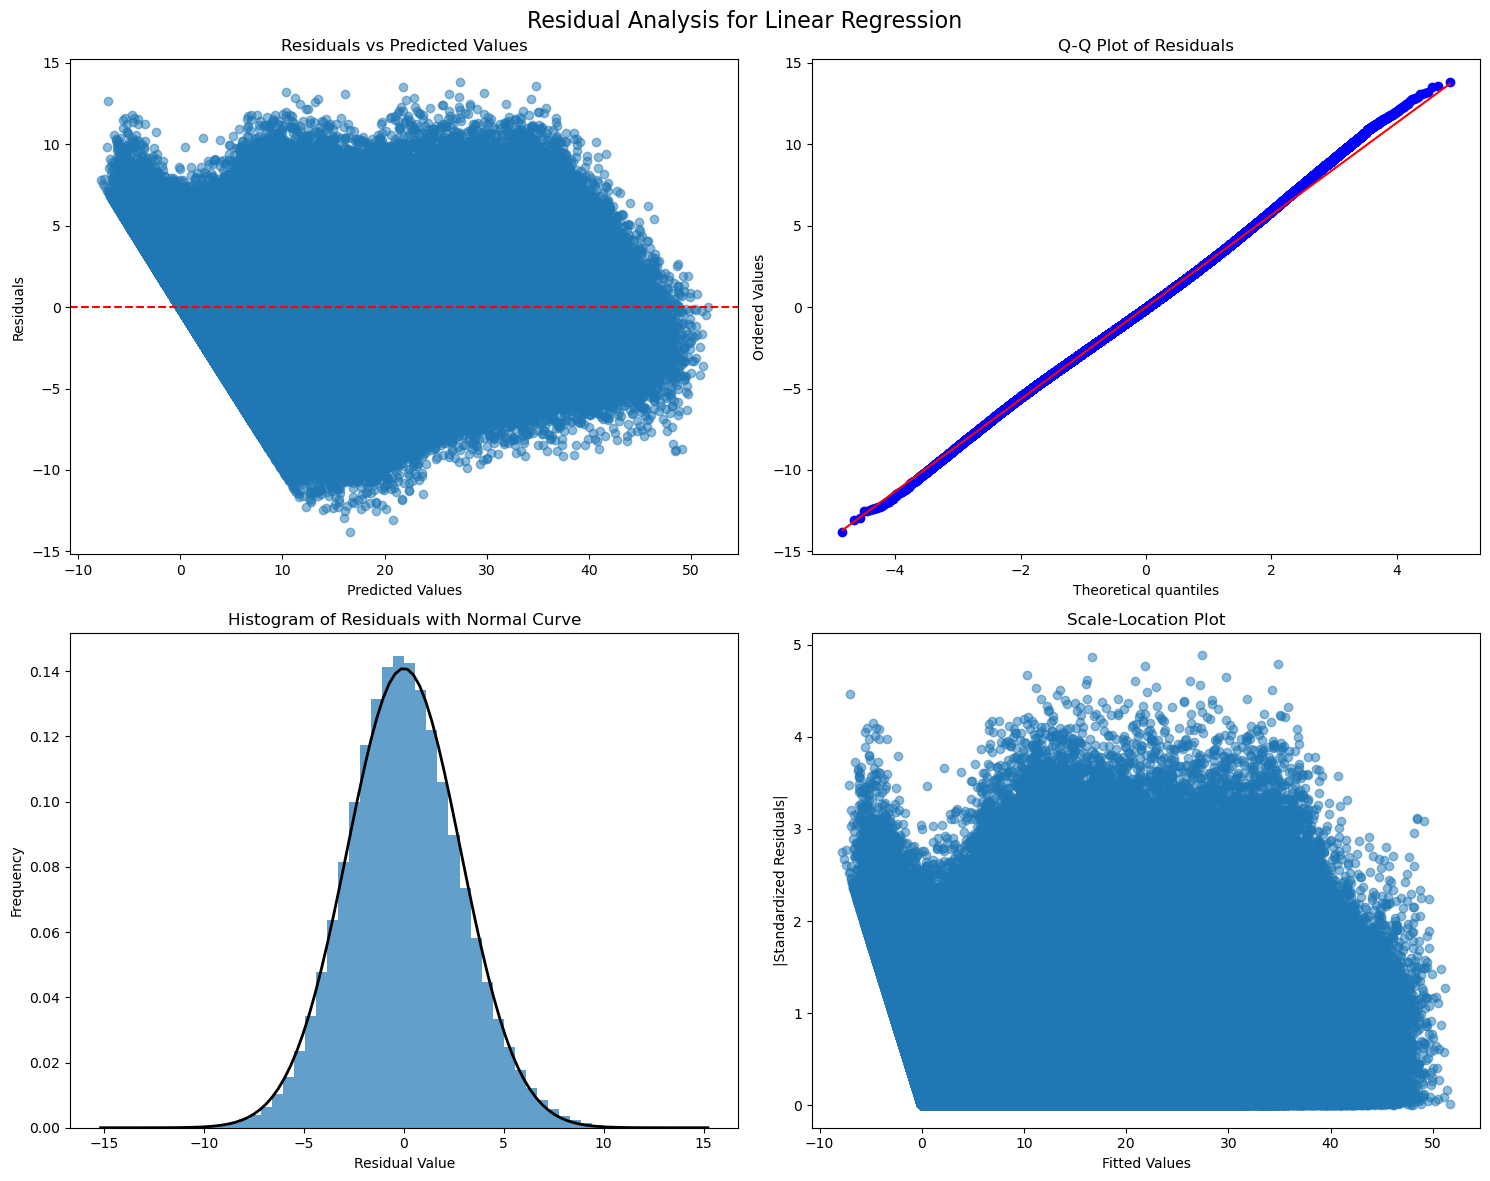


Residual Analysis Metrics:
Mean of residuals: 0.000000
Standard deviation of residuals: 2.831545
Skewness: 0.118009
Kurtosis: 0.198709

Statistical Tests:
Shapiro-Wilk test p-value: 0.000000
Null hypothesis: residuals are normally distributed
Conclusion: Reject null hypothesis at 5% significance level

Durbin-Watson statistic: 2.000444
Note: DW stat ranges from 0 to 4, with 2 indicating no autocorrelation
Conclusion: No significant autocorrelation

Breusch-Pagan test p-value: 0.000000
Null hypothesis: residuals have constant variance (homoscedasticity)
Conclusion: Reject null hypothesis at 5% significance level


In [12]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson


# Calculate residuals for both training and test sets
train_residuals = y_train - linear_model.predict(X_train_scaled)
test_residuals = y_test - linear_pred_test

# Create a figure with multiple subplots for residual analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Residual Analysis for Linear Regression', fontsize=16)

# 1. Residuals vs Predicted Values Plot
axes[0,0].scatter(linear_model.predict(X_train_scaled), train_residuals, alpha=0.5)
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_xlabel('Predicted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Predicted Values')

# 2. QQ Plot for normality check
stats.probplot(train_residuals, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot of Residuals')

# 3. Histogram of residuals
axes[1,0].hist(train_residuals, bins=50, density=True, alpha=0.7)
mu, std = np.mean(train_residuals), np.std(train_residuals)
xmin, xmax = axes[1,0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[1,0].plot(x, p, 'k', linewidth=2)
axes[1,0].set_title('Histogram of Residuals with Normal Curve')
axes[1,0].set_xlabel('Residual Value')
axes[1,0].set_ylabel('Frequency')

# 4. Scale-Location Plot (Spread-Location Plot)
fitted_values = linear_model.predict(X_train_scaled)
standardized_residuals = train_residuals / np.std(train_residuals)
axes[1,1].scatter(fitted_values, np.abs(standardized_residuals), alpha=0.5)
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('|Standardized Residuals|')
axes[1,1].set_title('Scale-Location Plot')

plt.tight_layout()
plt.show()

# Calculate numerical metrics for residuals
print("\nResidual Analysis Metrics:")
print(f"Mean of residuals: {np.mean(train_residuals):.6f}")
print(f"Standard deviation of residuals: {np.std(train_residuals):.6f}")
print(f"Skewness: {stats.skew(train_residuals):.6f}")
print(f"Kurtosis: {stats.kurtosis(train_residuals):.6f}")

# Statistical Tests
print("\nStatistical Tests:")

# 1. Shapiro-Wilk test for normality
_, p_value_normality = stats.shapiro(train_residuals)
print(f"Shapiro-Wilk test p-value: {p_value_normality:.6f}")
print("Null hypothesis: residuals are normally distributed")
print(f"Conclusion: {'Reject' if p_value_normality < 0.05 else 'Fail to reject'} null hypothesis at 5% significance level")

# 2. Durbin-Watson test for autocorrelation
dw_statistic = durbin_watson(train_residuals)
print(f"\nDurbin-Watson statistic: {dw_statistic:.6f}")
print("Note: DW stat ranges from 0 to 4, with 2 indicating no autocorrelation")
print(f"Conclusion: {'Potential autocorrelation' if dw_statistic < 1.5 or dw_statistic > 2.5 else 'No significant autocorrelation'}")

# 3. Breusch-Pagan test for heteroscedasticity (with constant term)
X_with_constant = sm.add_constant(X_train_scaled)
_, p_value_bp, _, _ = sm.stats.diagnostic.het_breuschpagan(train_residuals, X_with_constant)
print(f"\nBreusch-Pagan test p-value: {p_value_bp:.6f}")
print("Null hypothesis: residuals have constant variance (homoscedasticity)")
print(f"Conclusion: {'Reject' if p_value_bp < 0.05 else 'Fail to reject'} null hypothesis at 5% significance level")


Parameters for ridge regression

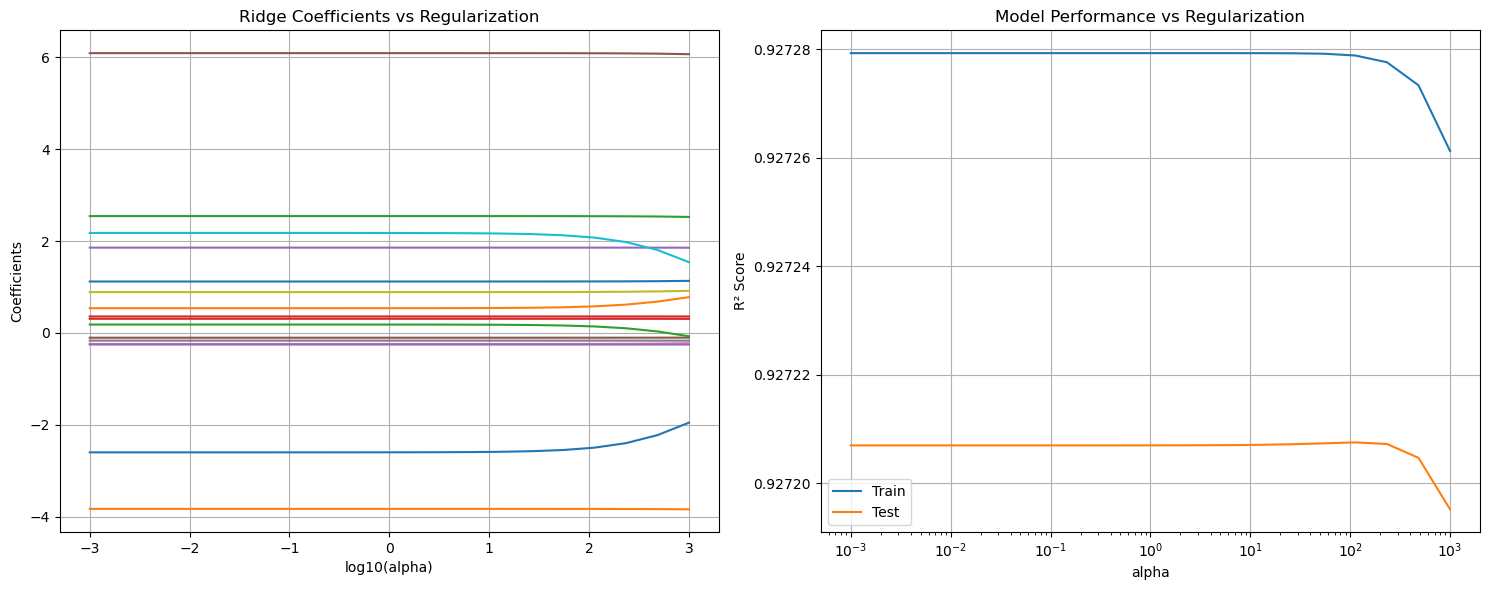


Optimal alpha: 112.883789
Best test R² score: 0.927208

Top 10 most important features and their coefficients at different regularization strengths:
               Feature  Weak Regularization (α=1.00e-03)  \
15           Intrinsic                          6.091979   
1         Strike Price                         -3.833433   
2   Time to Expiration                          2.543027   
10                  d2                         -2.602618   
9                   d1                          2.175881   
4           Volatility                          1.856437   
0          Stock Price                          1.118352   
8             Vol_Time                          0.887398   
11                N_d1                          0.537085   
3       Risk-Free Rate                          0.357539   

    Optimal Regularization (α=1.13e+02)  Strong Regularization (α=1.00e+03)  
15                             6.089364                            6.069085  
1                             -3.

In [13]:
# Define a range of alphas (regularization parameters)
alphas = np.logspace(-3, 3, 20)  # From 0.001 to 1000

# Lists to store results
train_scores = []
test_scores = []
coef_paths = []

# Train Ridge models with different alphas
for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_scaled, y_train)
    
    # Store scores
    train_scores.append(r2_score(y_train, ridge.predict(X_train_scaled)))
    test_scores.append(r2_score(y_test, ridge.predict(X_test_scaled)))
    coef_paths.append(ridge.coef_)

# Convert to numpy arrays for easier plotting
coef_paths = np.array(coef_paths)

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Coefficient paths
ax1.plot(np.log10(alphas), coef_paths)
ax1.set_xlabel('log10(alpha)')
ax1.set_ylabel('Coefficients')
ax1.set_title('Ridge Coefficients vs Regularization')
ax1.grid(True)

# Plot 2: Training and test scores
ax2.semilogx(alphas, train_scores, label='Train')
ax2.semilogx(alphas, test_scores, label='Test')
ax2.set_xlabel('alpha')
ax2.set_ylabel('R² Score')
ax2.set_title('Model Performance vs Regularization')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Find optimal alpha
optimal_idx = np.argmax(test_scores)
optimal_alpha = alphas[optimal_idx]

print(f"\nOptimal alpha: {optimal_alpha:.6f}")
print(f"Best test R² score: {test_scores[optimal_idx]:.6f}")

# Analyze coefficient behavior at different regularization strengths
# Get feature names
feature_names = X_train_enhanced.columns

# Compare coefficients at different regularization strengths
weak_reg = Ridge(alpha=alphas[0], random_state=42).fit(X_train_scaled, y_train)
optimal_reg = Ridge(alpha=optimal_alpha, random_state=42).fit(X_train_scaled, y_train)
strong_reg = Ridge(alpha=alphas[-1], random_state=42).fit(X_train_scaled, y_train)

# Create coefficient comparison DataFrame
coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Weak Regularization (α={:.2e})'.format(alphas[0]): weak_reg.coef_,
    'Optimal Regularization (α={:.2e})'.format(optimal_alpha): optimal_reg.coef_,
    'Strong Regularization (α={:.2e})'.format(alphas[-1]): strong_reg.coef_
})

# Sort by absolute coefficient values at optimal regularization
coef_comparison['Abs_Optimal'] = abs(coef_comparison['Optimal Regularization (α={:.2e})'.format(optimal_alpha)])
coef_comparison = coef_comparison.sort_values('Abs_Optimal', ascending=False).drop('Abs_Optimal', axis=1)

print("\nTop 10 most important features and their coefficients at different regularization strengths:")
print(coef_comparison.head(10))

# Calculate coefficient shrinkage
print("\nCoefficient Shrinkage Analysis:")
print("Total coefficient magnitude (L2 norm):")
print(f"Weak regularization: {np.linalg.norm(weak_reg.coef_):.2f}")
print(f"Optimal regularization: {np.linalg.norm(optimal_reg.coef_):.2f}")
print(f"Strong regularization: {np.linalg.norm(strong_reg.coef_):.2f}")


Paramaters for Lasso

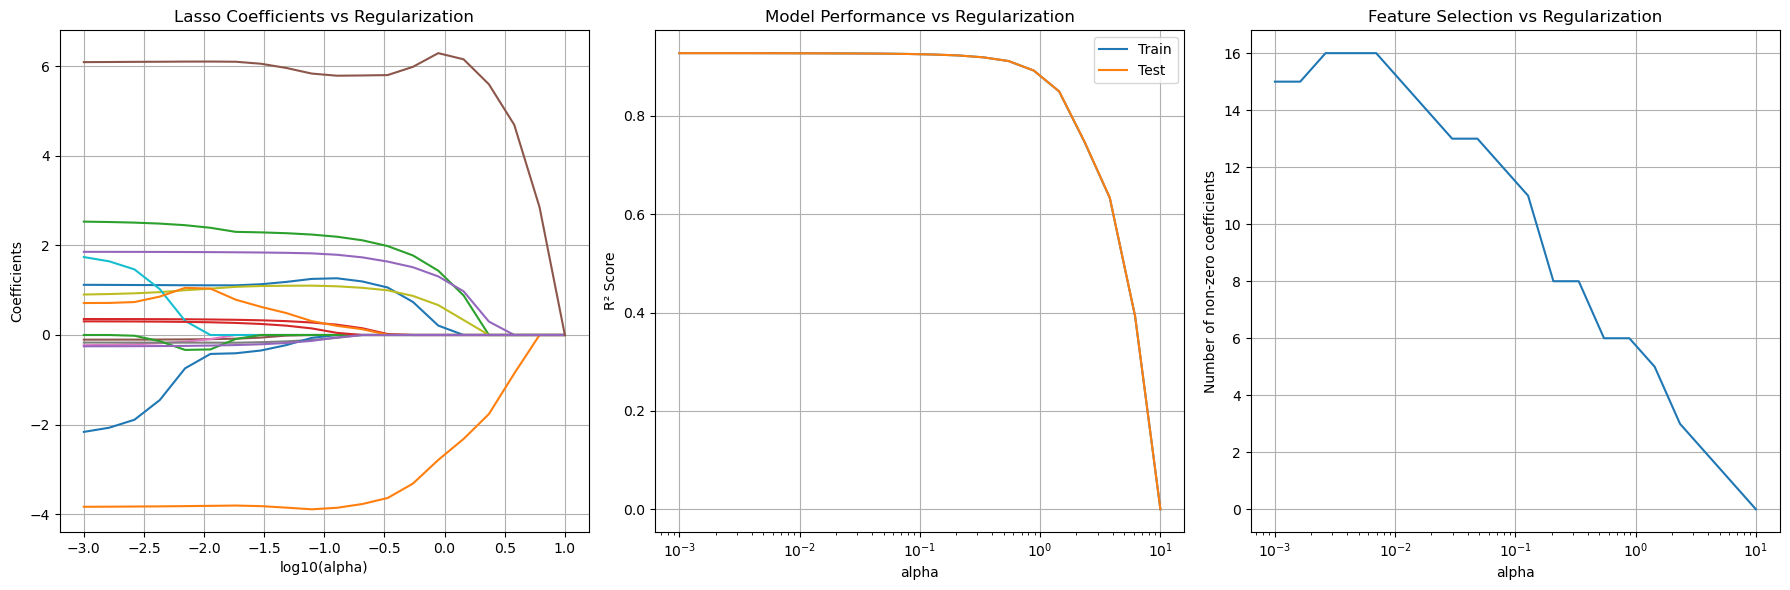


Optimal alpha: 0.001000
Best test R² score: 0.927204
Number of features used: 15 out of 16

Top 10 most important features and their coefficients at different regularization strengths:
               Feature  Weak Regularization (α=1.00e-03)  \
15           Intrinsic                          6.089378   
1         Strike Price                         -3.833731   
2   Time to Expiration                          2.529680   
10                  d2                         -2.162435   
4           Volatility                          1.855942   
9                   d1                          1.739083   
0          Stock Price                          1.119630   
8             Vol_Time                          0.903490   
11                N_d1                          0.713469   
3       Risk-Free Rate                          0.356557   

    Optimal Regularization (α=1.00e-03)  Strong Regularization (α=1.00e+01)  
15                             6.089378                                 0.0

In [14]:
from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd

# Define a range of alphas (regularization parameters)
alphas = np.logspace(-3, 1, 20)  # From 0.001 to 10

# Lists to store results
train_scores = []
test_scores = []
coef_paths = []
nonzero_coefs = []

# Train Lasso models with different alphas
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    
    # Store scores
    train_scores.append(r2_score(y_train, lasso.predict(X_train_scaled)))
    test_scores.append(r2_score(y_test, lasso.predict(X_test_scaled)))
    coef_paths.append(lasso.coef_)
    nonzero_coefs.append(np.sum(lasso.coef_ != 0))

# Convert to numpy arrays for easier plotting
coef_paths = np.array(coef_paths)

# Create plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Coefficient paths
ax1.plot(np.log10(alphas), coef_paths)
ax1.set_xlabel('log10(alpha)')
ax1.set_ylabel('Coefficients')
ax1.set_title('Lasso Coefficients vs Regularization')
ax1.grid(True)

# Plot 2: Training and test scores
ax2.semilogx(alphas, train_scores, label='Train')
ax2.semilogx(alphas, test_scores, label='Test')
ax2.set_xlabel('alpha')
ax2.set_ylabel('R² Score')
ax2.set_title('Model Performance vs Regularization')
ax2.grid(True)
ax2.legend()

# Plot 3: Number of non-zero coefficients
ax3.semilogx(alphas, nonzero_coefs)
ax3.set_xlabel('alpha')
ax3.set_ylabel('Number of non-zero coefficients')
ax3.set_title('Feature Selection vs Regularization')
ax3.grid(True)

plt.tight_layout()
plt.show()

# Find optimal alpha
optimal_idx = np.argmax(test_scores)
optimal_alpha = alphas[optimal_idx]

print(f"\nOptimal alpha: {optimal_alpha:.6f}")
print(f"Best test R² score: {test_scores[optimal_idx]:.6f}")
print(f"Number of features used: {nonzero_coefs[optimal_idx]} out of {X_train_scaled.shape[1]}")

# Analyze coefficient behavior at different regularization strengths
# Get feature names
feature_names = X_train_enhanced.columns

# Compare coefficients at different regularization strengths
weak_reg = Lasso(alpha=alphas[0], max_iter=10000, random_state=42).fit(X_train_scaled, y_train)
optimal_reg = Lasso(alpha=optimal_alpha, max_iter=10000, random_state=42).fit(X_train_scaled, y_train)
strong_reg = Lasso(alpha=alphas[-1], max_iter=10000, random_state=42).fit(X_train_scaled, y_train)

# Create coefficient comparison DataFrame
coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Weak Regularization (α={:.2e})'.format(alphas[0]): weak_reg.coef_,
    'Optimal Regularization (α={:.2e})'.format(optimal_alpha): optimal_reg.coef_,
    'Strong Regularization (α={:.2e})'.format(alphas[-1]): strong_reg.coef_
})

# Sort by absolute coefficient values at optimal regularization
coef_comparison['Abs_Optimal'] = abs(coef_comparison['Optimal Regularization (α={:.2e})'.format(optimal_alpha)])
coef_comparison = coef_comparison.sort_values('Abs_Optimal', ascending=False).drop('Abs_Optimal', axis=1)

print("\nTop 10 most important features and their coefficients at different regularization strengths:")
print(coef_comparison.head(10))

# Show features that get eliminated at optimal regularization
eliminated_features = coef_comparison[coef_comparison['Optimal Regularization (α={:.2e})'.format(optimal_alpha)] == 0]
print(f"\nFeatures eliminated at optimal regularization ({len(eliminated_features)} features):")
print(eliminated_features['Feature'].values)

# Calculate coefficient sparsity
print("\nCoefficient Sparsity Analysis:")
print(f"Weak regularization: {np.sum(weak_reg.coef_ != 0)} non-zero coefficients out of {len(weak_reg.coef_)}")
print(f"Optimal regularization: {np.sum(optimal_reg.coef_ != 0)} non-zero coefficients out of {len(optimal_reg.coef_)}")
print(f"Strong regularization: {np.sum(strong_reg.coef_ != 0)} non-zero coefficients out of {len(strong_reg.coef_)}")


High Var (5) dataset analysis for accuracy for ridge and lassos

In [23]:
# Train models on normal data
ridge_normal = Ridge(alpha=0.1)
ridge_normal.fit(X_train_scaled, y_train)
ridge_normal_r2 = r2_score(y_test, ridge_normal.predict(X_test_scaled))

lasso_normal = Lasso(alpha=0.1)
lasso_normal.fit(X_train_scaled, y_train)
lasso_normal_r2 = r2_score(y_test, lasso_normal.predict(X_test_scaled))

# Train models on noisy data
ridge_noisy = Ridge(alpha=0.1)
ridge_noisy.fit(X_train_scaled_noisy, y_noisy_train)
ridge_noisy_r2 = r2_score(y_noisy_test, ridge_noisy.predict(X_test_scaled_noisy))

lasso_noisy = Lasso(alpha=0.1)
lasso_noisy.fit(X_train_scaled_noisy, y_noisy_train)
lasso_noisy_r2 = r2_score(y_noisy_test, lasso_noisy.predict(X_test_scaled_noisy))

print("Normal vs High Volatility Performance:")
print(f"Ridge - Normal R²: {ridge_normal_r2:.4f}")
print(f"Ridge - High Volatility R²: {ridge_noisy_r2:.4f}")
print(f"Lasso - Normal R²: {lasso_normal_r2:.4f}")
print(f"Lasso - High Volatility R²: {lasso_noisy_r2:.4f}")


Normal vs High Volatility Performance:
Ridge - Normal R²: 0.9272
Ridge - High Volatility R²: 1.0000
Lasso - Normal R²: 0.9251
Lasso - High Volatility R²: 0.9999
